In [2]:
# Malaria datasetini KaggleHub ile indiriyoruz

import kagglehub

dataset_path = kagglehub.dataset_download(
    "iarunava/cell-images-for-detecting-malaria"
)

print(dataset_path)

/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria


In [3]:
# Dataset klasörlerini kontrol ediyoruz

import os

base_path = dataset_path + "/cell_images/cell_images"

print(os.listdir(base_path))

['Uninfected', 'Parasitized']


# 🧠 Transfer Learning - VGG16

Bu projede hazır eğitilmiş VGG16 modeli kullanılarak malaria hücre görüntüleri sınıflandırılacaktır.

In [4]:
# Gerekli kütüphaneleri import ediyoruz

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications.vgg16 import VGG16

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Flatten, Dropout

from tensorflow.keras.optimizers import Adam

2026-05-17 14:21:38.494542: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779027698.522406     222 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779027698.530732     222 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779027698.551930     222 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779027698.551961     222 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779027698.551966     222 computation_placer.cc:177] computation placer alr

In [5]:
# ImageDataGenerator oluşturuyoruz

datagen = ImageDataGenerator(
    rescale=1/255,
    validation_split=0.2
)

In [6]:
# Train verisini oluşturuyoruz

train_data = datagen.flow_from_directory(
    base_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

Found 22048 images belonging to 2 classes.


In [7]:
# Validation verisini oluşturuyoruz

val_data = datagen.flow_from_directory(
    base_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 5510 images belonging to 2 classes.


In [8]:
# Hazır VGG16 modelini yüklüyoruz

vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128,128,3)
)

2026-05-17 14:21:57.109112: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
# VGG16 katmanlarını donduruyoruz

for layer in vgg.layers:
    layer.trainable = False

In [10]:
# Transfer Learning modelini oluşturuyoruz

model = Sequential()

model.add(vgg)

model.add(Flatten())

model.add(Dense(128, activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

In [11]:
# Model özetini inceliyoruz

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,763,521 (60.13 MB)

 Trainable params: 1,048,833 (4.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
# Modeli derliyoruz

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [13]:
# VGG16 modelini eğitiyoruz

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


689/689 ━━━━━━━━━━━━━━━━━━━━ 2748s 4s/step - accuracy: 0.8145 - loss: 0.3964 - val_accuracy: 0.9018 - val_loss: 0.2292
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 2762s 4s/step - accuracy: 0.9243 - loss: 0.1996 - val_accuracy: 0.9230 - val_loss: 0.1869
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 2716s 4s/step - accuracy: 0.9334 - loss: 0.1736 - val_accuracy: 0.9278 - val_loss: 0.1767
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 2713s 4s/step - accuracy: 0.9393 - loss: 0.1624 - val_accuracy: 0.9169 - val_loss: 0.2027
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 2737s 4s/step - accuracy: 0.9445 - loss: 0.1491 - val_accuracy: 0.9158 - val_loss: 0.2163


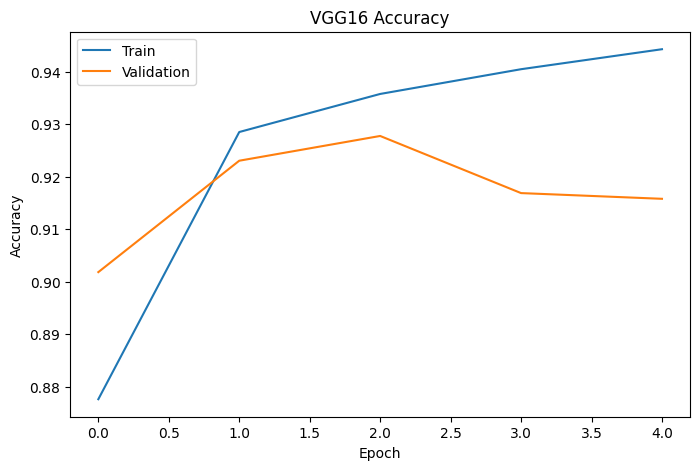

In [14]:
# Accuracy değişimini görselleştiriyoruz

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("VGG16 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()



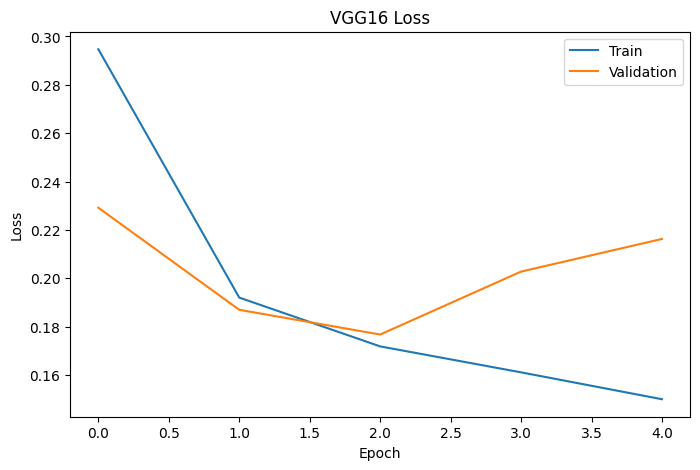

In [15]:
# Loss değişimini görselleştiriyoruz

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("VGG16 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

# 📌 Proje Sonucu

Bu projede Transfer Learning yaklaşımı kullanılarak VGG16 modeli ile malaria hücre görüntüleri sınıflandırılmıştır.

Model:
- Parasitized
- Uninfected

olmak üzere iki sınıf üzerinde eğitilmiştir.

Bu proje kapsamında:
- Transfer Learning
- VGG16
- ImageDataGenerator
- CNN mimarisi
- Feature Extraction
- Deep Learning image classification

uygulanmıştır.

Model yaklaşık %92-93 validation accuracy başarısı göstermiştir.